# Rice Variety Classification - End-to-End Pipeline

This notebook runs the entire pipeline for the Rice Variety Classification project.

## §0 - Environment Setup



In [1]:
import os
import sys

if 'google.colab' in sys.modules:

    REPO_URL = "https://github.com/powerofdarkine/riceclassifier.git"

    if not os.path.exists('riceclassifier'):
        !git clone {REPO_URL} riceclassifier

    os.chdir('riceclassifier')

    !pip install -q xgboost scikit-learn pandas matplotlib seaborn

sys.path.append(os.path.abspath('.'))


Cloning into 'riceclassifier'...
remote: Enumerating objects: 147, done.
remote: Counting objects: 100% (32/32), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 147 (delta 6), reused 15 (delta 3), pack-reused 115 (from 1)
Receiving objects: 100% (147/147), 178.39 MiB | 18.67 MiB/s, done.
Resolving deltas: 100% (42/42), done.


## §1 - Dataset Download & Preparation
Download the ARUZZ225K dataset from Mendeley (Original.zip) and extract it.


In [2]:
import os
import urllib.request
import zipfile

DATA_DIR = "data"
ORIGINAL_DIR = os.path.join(DATA_DIR, "Original")

# Create data directory
os.makedirs(DATA_DIR, exist_ok=True)

TARGET_FILE = "Original.zip"
DOWNLOAD_URL = "https://data.mendeley.com/public-files/datasets/3mn9843tz2/files/14beed89-e936-43f3-ac6a-55ef732f5245/file_downloaded"

zip_path = os.path.join(DATA_DIR, TARGET_FILE)

def make_request(url):
    return urllib.request.Request(
        url,
        headers={
            "User-Agent": "Mozilla/5.0 (compatible; riceclassifier/1.0)",
            "Accept": "*/*",
        },
    )

def download_file(url, destination):
    temp_destination = destination + ".part"
    if os.path.exists(temp_destination):
        os.remove(temp_destination)

    with urllib.request.urlopen(make_request(url), timeout=120) as response:
        total_size = int(response.headers.get("Content-Length", 0))
        downloaded = 0
        last_reported = 0

        with open(temp_destination, "wb") as output_file:
            while True:
                chunk = response.read(1024 * 1024)
                if not chunk:
                    break
                output_file.write(chunk)
                downloaded += len(chunk)

                if downloaded - last_reported >= 50 * 1024 * 1024:
                    if total_size:
                        print(f"Downloaded {downloaded / (1024 ** 2):.1f} MB / {total_size / (1024 ** 2):.1f} MB")
                    else:
                        print(f"Downloaded {downloaded / (1024 ** 2):.1f} MB")
                    last_reported = downloaded

    os.replace(temp_destination, destination)

def safe_extract(zip_file, destination):
    destination_abs = os.path.abspath(destination)
    for member in zip_file.infolist():
        member_path = os.path.abspath(os.path.join(destination, member.filename))
        if not member_path.startswith(destination_abs + os.sep) and member_path != destination_abs:
            raise RuntimeError(f"Unsafe path in zip file: {member.filename}")
    zip_file.extractall(destination)

if not os.path.exists(ORIGINAL_DIR):
    if os.path.exists(zip_path) and not zipfile.is_zipfile(zip_path):
        print(f"Existing {zip_path} is not a valid zip file. Re-downloading it...")
        os.remove(zip_path)

    if not os.path.exists(zip_path):
        print(f"Downloading {TARGET_FILE} from Mendeley: {DOWNLOAD_URL}")
        print("Downloading dataset from Mendeley. Please wait, this might take a few minutes...")
        download_file(DOWNLOAD_URL, zip_path)
        print("Download complete.")

    if os.path.exists(zip_path):
        print("Extracting dataset...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            safe_extract(zip_ref, DATA_DIR)
        print("Extraction complete.")
else:
    print("Dataset already downloaded and extracted.")


Downloaded 50.0 MB / 254.6 MB
Downloaded 100.0 MB / 254.6 MB
Downloaded 150.0 MB / 254.6 MB
Downloaded 200.0 MB / 254.6 MB
Downloaded 250.0 MB / 254.6 MB
Download complete.
Extracting dataset...
Extraction complete.


## §2 - Exploratory Data Analysis (EDA)
The following cells contain the EDA pipeline.

# EDA

In [3]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
TARGET_SIZE = (224, 224)

DATASET_PATH = Path('data/Original')

def get_class_distribution(base_path):
    """
    Scans the base directory, treating each subfolder as a class,
    and counts the number of image files within each.
    """
    class_counts = {}
    total_samples = 0

    if not base_path.exists():
        print(f"Error: The path {base_path} could not be found.")
        return None, 0

    for class_dir in base_path.iterdir():
        if class_dir.is_dir():
            class_name = class_dir.name

            # Count valid image files in the subfolder
            count = sum(1 for f in class_dir.glob('*.*') if f.suffix.lower() in ['.jpg', '.png', '.jpeg'])

            class_counts[class_name] = count
            total_samples += count

    # Convert pandas DataFrame
    df_counts = pd.DataFrame(list(class_counts.items()), columns=['Rice Type', 'Sample Count'])

    # Sort the dataframe from highest to lowest
    df_counts = df_counts.sort_values(by='Sample Count', ascending=False).reset_index(drop=True)

    return df_counts, total_samples

# ==========================================
# Execution
# ==========================================
distribution_df, total_images = get_class_distribution(DATASET_PATH)

if distribution_df is not None:
    print(f"Total Samples (All Types Combined): {total_images}")
    print(f"Total Unique Rice Types: {len(distribution_df)}")
    print("\n--- Distribution per Rice Type ---")
    display(distribution_df)

Total Samples (All Types Combined): 4730
Total Unique Rice Types: 20

--- Distribution per Rice Type ---


,Rice Type,Sample Count
0,12_Gutisharna,256
1,9_Bashful,252
2,18_Amon,250
3,15_Katari_Polao,242
4,13_Red_Cargo,240
5,19_Shorna5,238
6,17_Chinigura_Polao,237
7,4_Shampakatari,234
8,8_Paijam,234
9,3_Ganjiya,233


1 Dataset Indexing

In [4]:
def index_dataset(base_path):
    """Indexes all images and their corresponding class labels from the directory structure."""
    dataset = []
    if not base_path.exists():
        return pd.DataFrame()

    for class_dir in base_path.iterdir():
        if class_dir.is_dir():
            label = class_dir.name
            for img_path in class_dir.glob('*.*'):
                if img_path.suffix.lower() in ['.jpg', '.png', '.jpeg']:
                    dataset.append({'image_path': str(img_path), 'label': label})

    return pd.DataFrame(dataset)

# Execute Indexing
dataset_index = index_dataset(DATASET_PATH)

if not dataset_index.empty:
    print(f"Indexing Complete: Found {len(dataset_index)} images across {dataset_index['label'].nunique()} classes.")
    print("\n--- Dataset Index Information ---")
    dataset_index.info()
else:
    print("System Error: The specified DATASET_PATH could not be resolved.")

Indexing Complete: Found 4730 images across 20 classes.

--- Dataset Index Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4730 entries, 0 to 4729
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_path  4730 non-null   object
 1   label       4730 non-null   object
dtypes: object(2)
memory usage: 74.0+ KB


Sequential Image Processing & Extraction

In [5]:
def process_and_extract_features(row):
    """Reads the image, standardizes dimensions, and extracts features."""
    path = row['image_path']
    img = cv2.imread(path)
    if img is None:
        return None

    img_resized = cv2.resize(img, TARGET_SIZE)
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)

    # 1. Color Channel Statistics
    r_mean, g_mean, b_mean = np.mean(img_rgb, axis=(0, 1))

    # 2. Sharpness Evaluation
    gray = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY)
    blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()

    # 3. Morphological Feature Extraction
    _, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    area, aspect_ratio = 0.0, 0.0
    if contours:
        main_contour = max(contours, key=cv2.contourArea)
        area = cv2.contourArea(main_contour)
        x, y, w, h = cv2.boundingRect(main_contour)
        aspect_ratio = float(w) / h if h != 0 else 0.0

    return {
        'image_path': path, 'label': row['label'],
        'r_mean': r_mean, 'g_mean': g_mean, 'b_mean': b_mean,
        'blur_score': blur_score, 'grain_area': area, 'aspect_ratio': aspect_ratio
    }

# Execute Extraction
max_samples = 2000
sampled_df = dataset_index.sample(n=min(max_samples, len(dataset_index)), random_state=42)
print(f"Initiating feature extraction for {len(sampled_df)} standardized images...")

results = [process_and_extract_features(row) for _, row in sampled_df.iterrows()]
stats_df = pd.DataFrame([res for res in results if res is not None])

print("\n--- Extracted Features Information ---")
stats_df.info()

Initiating feature extraction for 2000 standardized images...

--- Extracted Features Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   image_path    2000 non-null   object 
 1   label         2000 non-null   object 
 2   r_mean        2000 non-null   float64
 3   g_mean        2000 non-null   float64
 4   b_mean        2000 non-null   float64
 5   blur_score    2000 non-null   float64
 6   grain_area    2000 non-null   float64
 7   aspect_ratio  2000 non-null   float64
dtypes: float64(6), object(2)
memory usage: 125.1+ KB


Visual Analytics

/tmp/ipykernel_2292/1991052236.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dataset_index, x='label', order=dataset_index['label'].value_counts().index, palette='viridis')


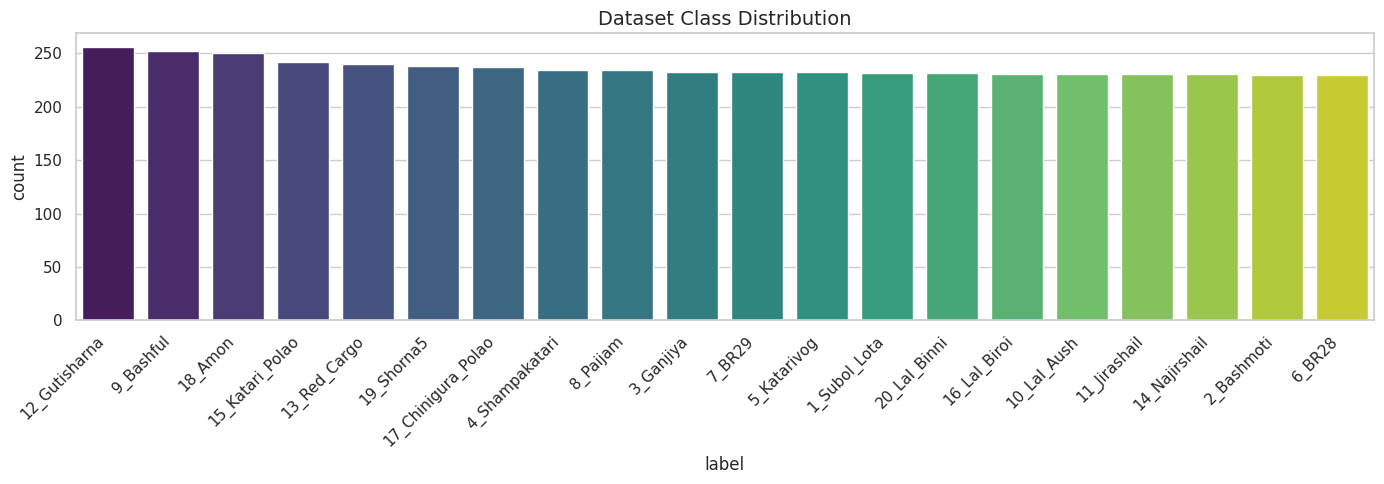

In [6]:
plt.figure(figsize=(14, 5))
sns.countplot(data=dataset_index, x='label', order=dataset_index['label'].value_counts().index, palette='viridis')
plt.title('Dataset Class Distribution', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

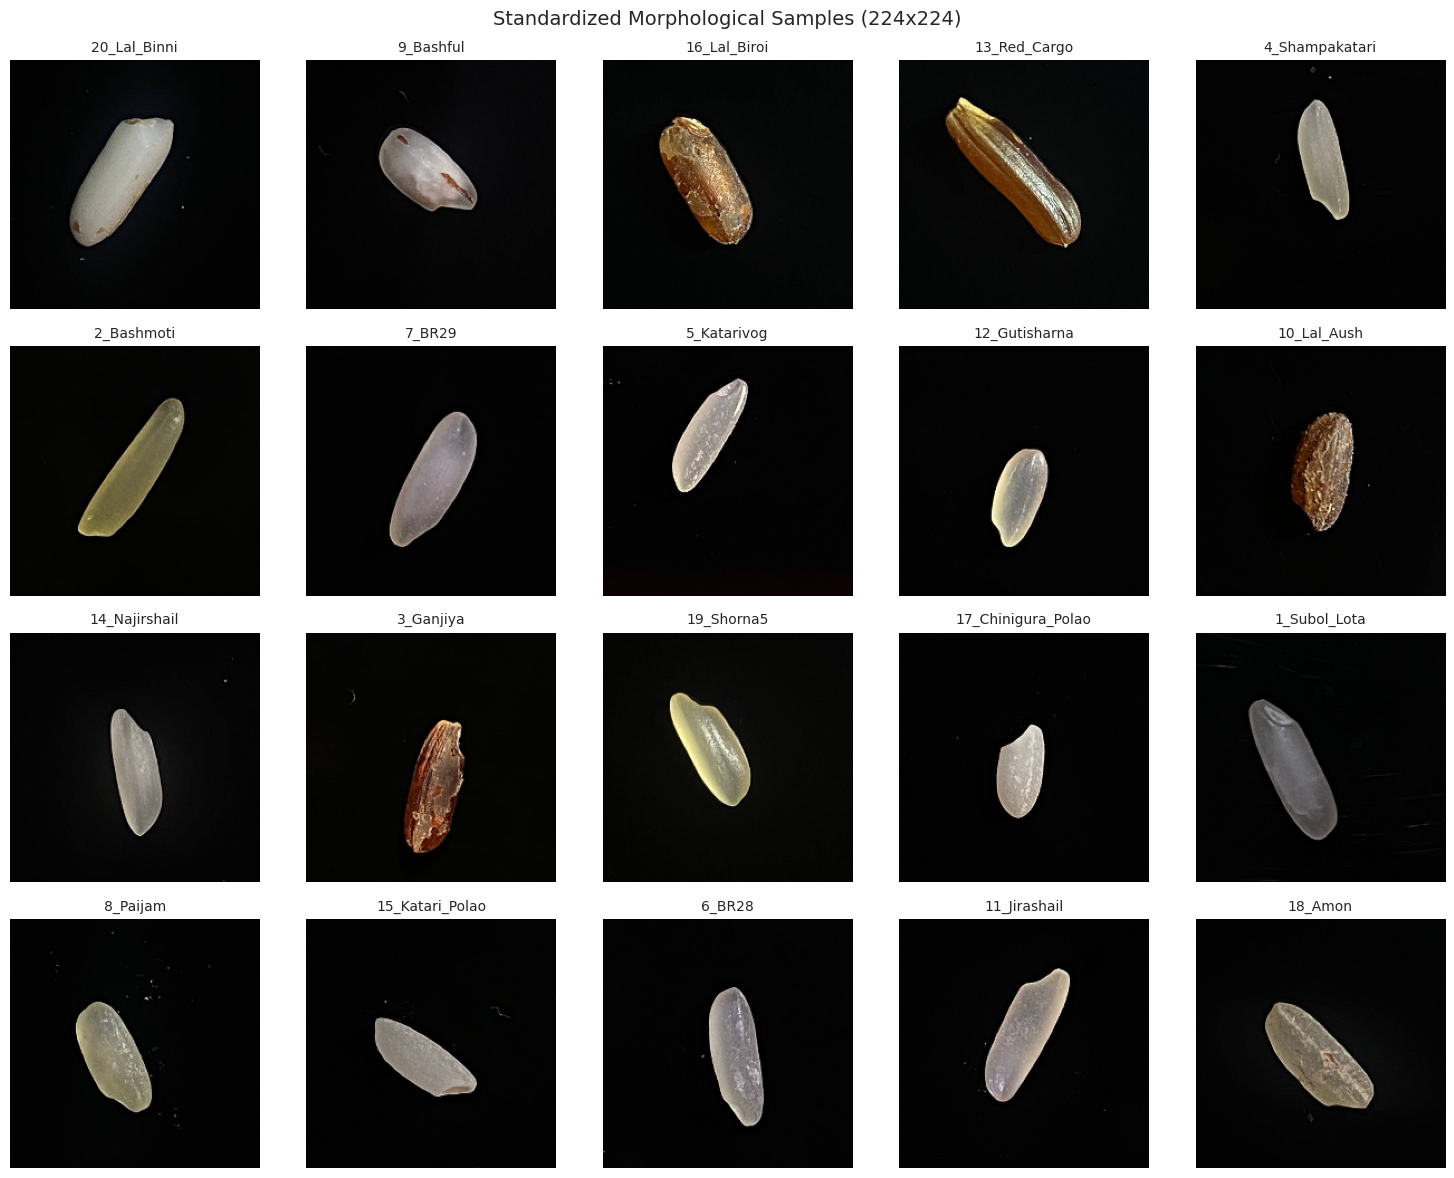

In [7]:
classes = dataset_index['label'].unique()
cols = 5
rows = min(4, (len(classes) + cols - 1) // cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
axes = axes.flatten()

for i, class_name in enumerate(classes[:20]):
    sample_path = random.choice(dataset_index[dataset_index['label'] == class_name]['image_path'].tolist())
    img = cv2.imread(sample_path)
    if img is not None:
        img_resized = cv2.resize(img, TARGET_SIZE)
        img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img_rgb)
        axes[i].set_title(class_name, fontsize=10)
    axes[i].axis('off')

for j in range(len(classes[:20]), len(axes)):
    axes[j].axis('off')

plt.suptitle("Standardized Morphological Samples (224x224)", fontsize=14)
plt.tight_layout()
plt.show()

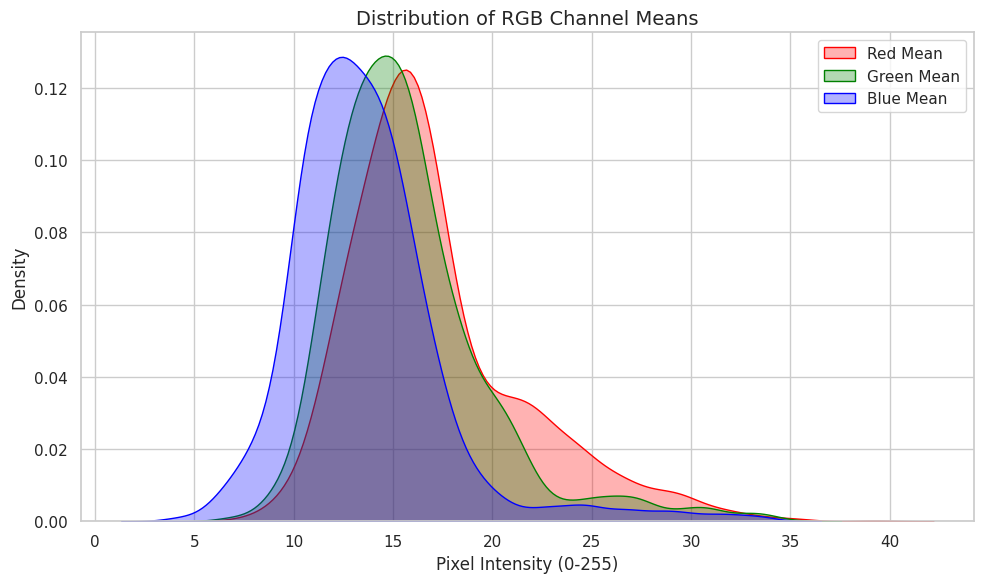

In [8]:
plt.figure(figsize=(10, 6))
sns.kdeplot(stats_df['r_mean'], color='red', label='Red Mean', fill=True, alpha=0.3)
sns.kdeplot(stats_df['g_mean'], color='green', label='Green Mean', fill=True, alpha=0.3)
sns.kdeplot(stats_df['b_mean'], color='blue', label='Blue Mean', fill=True, alpha=0.3)
plt.title('Distribution of RGB Channel Means', fontsize=14)
plt.xlabel('Pixel Intensity (0-255)')
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_2292/196184368.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], x='label', y='grain_area', data=stats_df, palette='Set2')
/tmp/ipykernel_2292/196184368.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_2292/196184368.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], x='label', y='aspect_ratio', data=stats_df, palette='Set3')
/tmp/ipykernel_2292/196184368.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a 

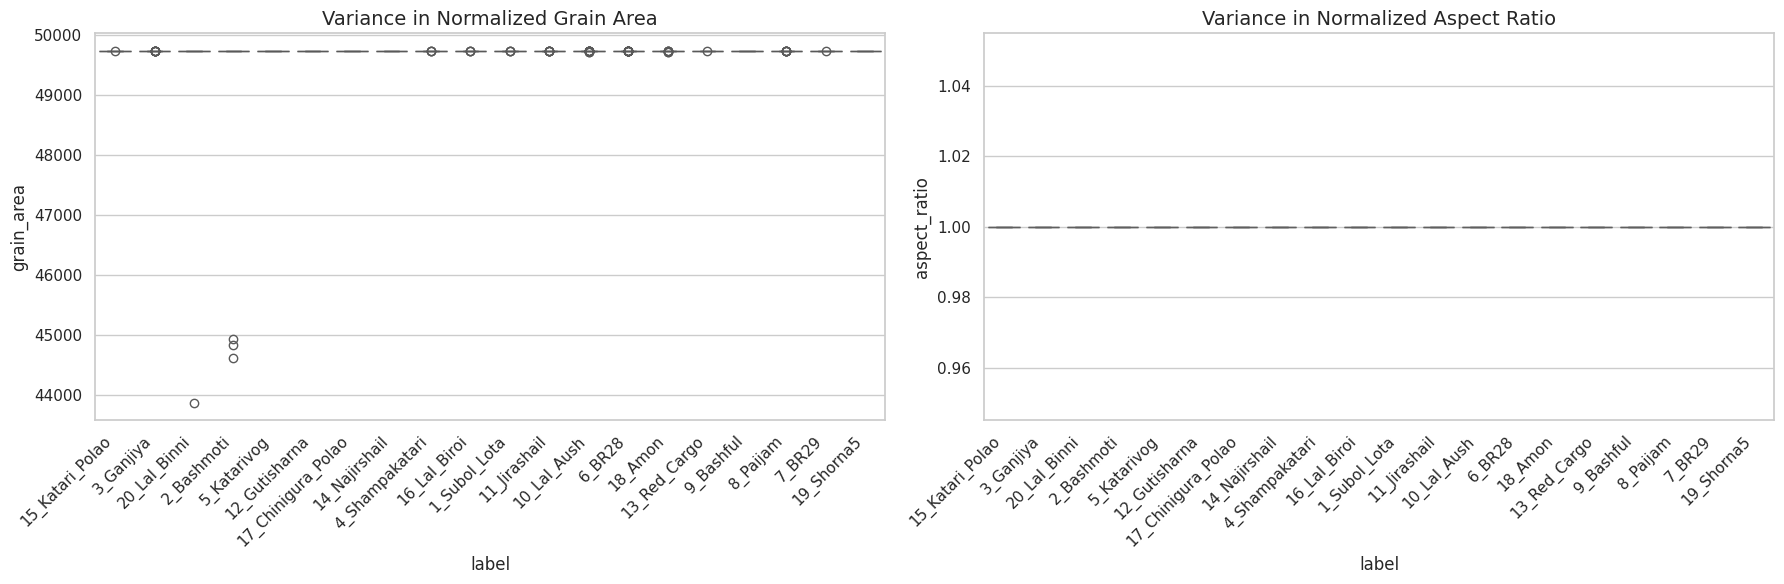

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.boxplot(ax=axes[0], x='label', y='grain_area', data=stats_df, palette='Set2')
axes[0].set_title('Variance in Normalized Grain Area', fontsize=14)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

sns.boxplot(ax=axes[1], x='label', y='aspect_ratio', data=stats_df, palette='Set3')
axes[1].set_title('Variance in Normalized Aspect Ratio', fontsize=14)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

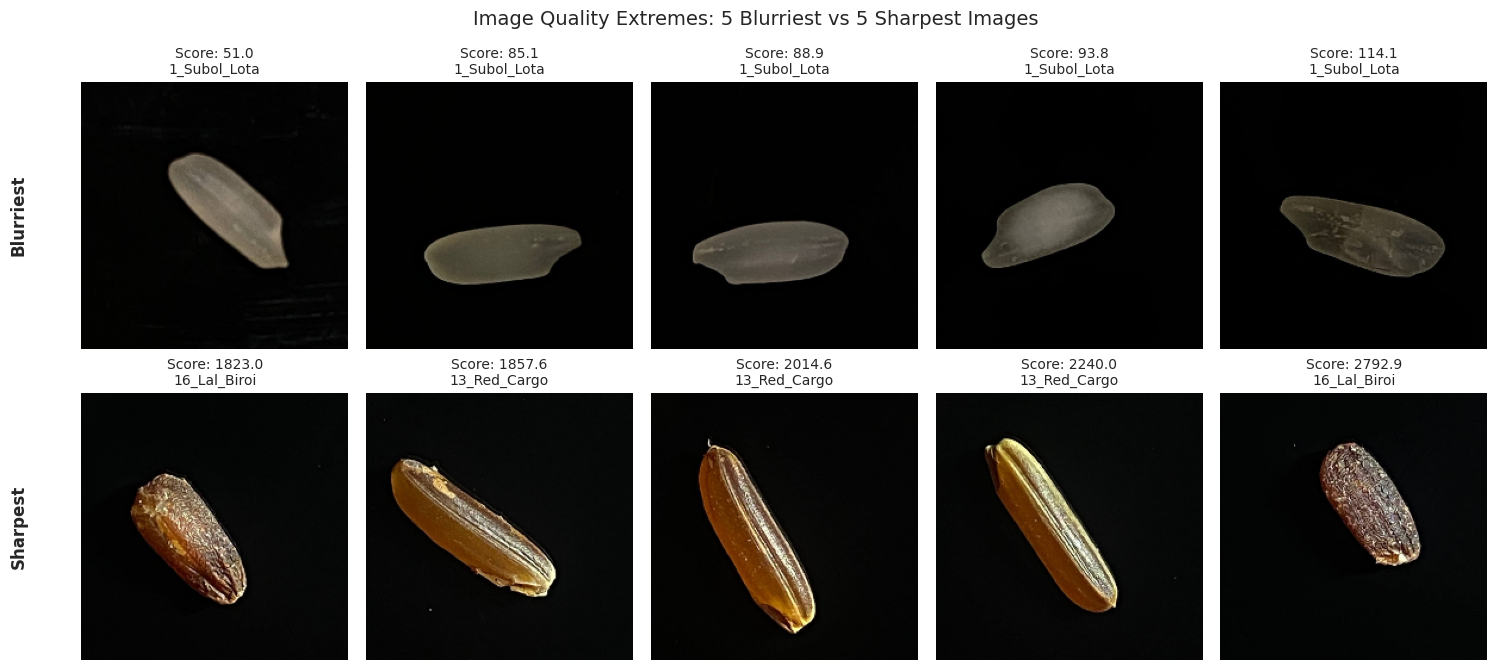

In [10]:
stats_sorted = stats_df.sort_values(by='blur_score')
blurry_samples = stats_sorted.head(5)
sharp_samples = stats_sorted.tail(5)

fig, axes = plt.subplots(2, 5, figsize=(15, 7))

for i, (_, row) in enumerate(blurry_samples.iterrows()):
    img = cv2.cvtColor(cv2.resize(cv2.imread(row['image_path']), TARGET_SIZE), cv2.COLOR_BGR2RGB)
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"Score: {row['blur_score']:.1f}\n{row['label']}", fontsize=10)
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].text(-0.2, 0.5, 'Blurriest', va='center', ha='right', rotation=90, transform=axes[0, i].transAxes, fontsize=12, fontweight='bold')

for i, (_, row) in enumerate(sharp_samples.iterrows()):
    img = cv2.cvtColor(cv2.resize(cv2.imread(row['image_path']), TARGET_SIZE), cv2.COLOR_BGR2RGB)
    axes[1, i].imshow(img)
    axes[1, i].set_title(f"Score: {row['blur_score']:.1f}\n{row['label']}", fontsize=10)
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].text(-0.2, 0.5, 'Sharpest', va='center', ha='right', rotation=90, transform=axes[1, i].transAxes, fontsize=12, fontweight='bold')

plt.suptitle("Image Quality Extremes: 5 Blurriest vs 5 Sharpest Images", fontsize=14)
plt.tight_layout()
plt.show()

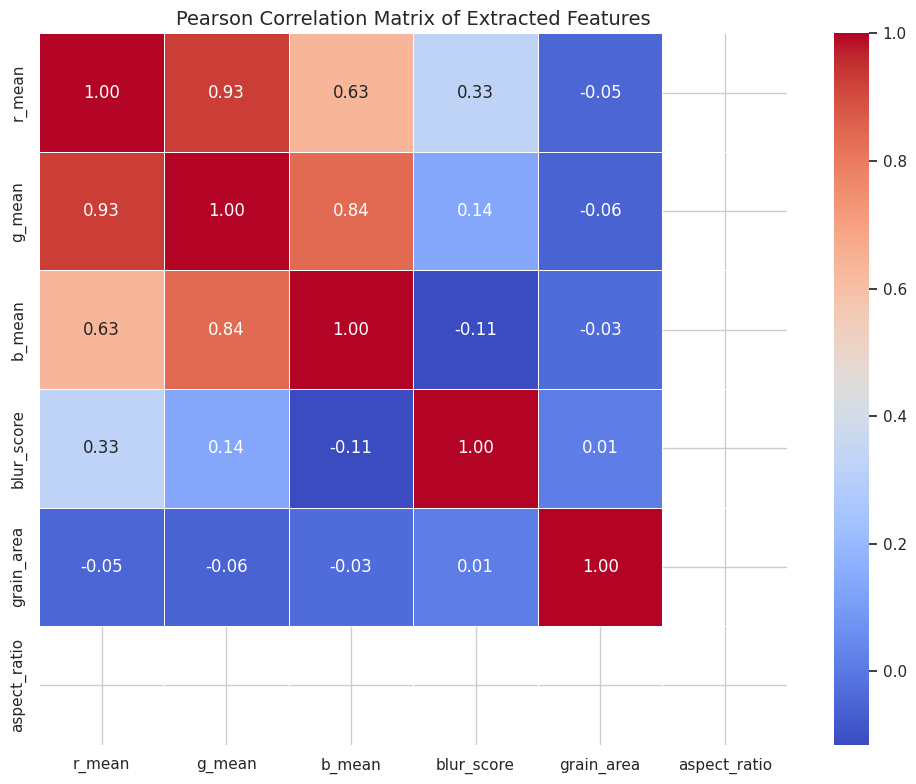

In [11]:
numeric_columns = ['r_mean', 'g_mean', 'b_mean', 'blur_score', 'grain_area', 'aspect_ratio']
correlation_data = stats_df[numeric_columns]

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_data.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Pearson Correlation Matrix of Extracted Features', fontsize=14)
plt.tight_layout()
plt.show()

## §3 - Feature Extraction
Extract features using pretrained backbones (VGG16, ResNet18, ViT-B/16) and save them as .npy files.


In [12]:
from modules.data_extractor import run_all_models

# Run extraction (this will save to results/features_all)
# We mock sys.argv if needed, but run_all_models handles it.
import argparse
from pathlib import Path

# The original code uses config.py defaults. We just run it directly.
print("Starting feature extraction...")
run_all_models({"out_root": "features"})


Starting feature extraction...

[EXTRACT] backbone=vgg16 | image_size=(224, 224) | device=cuda


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 176MB/s]
Extracting features:   0%|          | 0/89 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Extracting features: 100%|██████████| 89/89 [00:31<00:00,  2.79it/s]


  train: (2838, 4096) | labels=(2838,)


...

Extracting features: 100%|██████████| 30/30 [00:13<00:00,  2.26it/s]


  val: (946, 768) | labels=(946,)


Extracting features: 100%|██████████| 30/30 [00:13<00:00,  2.17it/s]

  test: (946, 768) | labels=(946,)
Saved features: features/vit_b_16_224x224


PosixPath('features')

## §4 - ML Benchmarks
Train classical ML models (LogReg, SVM, KNN, RF, XGBoost) on the extracted features.


In [13]:
from modules.ml_pipeline import main as run_ml
import sys
import copy

print("Starting ML pipeline benchmark...")

old_argv = copy.copy(sys.argv)
sys.argv = ['ml_pipeline.py', '--device', 'cuda', '--features-root', 'features']
run_ml()
sys.argv = old_argv


Starting ML pipeline benchmark...
[INFO] Using CuPy arrays for XGBoost CUDA data path.
[INFO] Using CUDA backend with cuML for supported models.
[INFO] Selected device=cuda, backend=cuda_cuml

=== Architecture: resnet18_224x224 ===
train=(2838, 512), val=(946, 512), test=(946, 512)
[2026-05-10 08:53:08.199] [CUML] [warning] L-BFGS stopped, because the line search failed to advance (step delta = 0.000000)
[2026-05-10 08:53:10.265] [CUML] [warning] L-BFGS: max iterations reached
[2026-05-10 08:53:10.266] [CUML] [warning] Maximum iterations reached before solver is converged. To increase model accuracy you can increase the number of iterations (max_iter) or improve the scaling of the input data.
           logreg | val_acc=0.9154 | test_acc=0.8901 | tune=6.0916s | best={"C": 3.0}
       linear_svm | val_acc=0.9038 | test_acc=0.8932 | tune=17.4307s | best={"C": 0.1}
              knn | val_acc=0.7928 | test_acc=0.7928 | tune=1.2896s | best={"n_neighbors": 9, "weights": "distance"}
    rand

In [14]:
from IPython.display import display
from pathlib import Path
import pandas as pd

ml_comparison_path = Path("results/ml_benchmarks/model_comparison_all.csv")
ml_best_path = Path("results/ml_benchmarks/best_model_per_architecture.csv")

if ml_comparison_path.exists():
    ml_results = pd.read_csv(ml_comparison_path)
    print("ML Results - All Models")
    display(ml_results.sort_values(["test_accuracy", "val_accuracy"], ascending=False))
else:
    print(f"No ML results found at: {ml_comparison_path}")

if ml_best_path.exists():
    ml_best = pd.read_csv(ml_best_path)
    print("\nML Best Model Per Architecture")
    display(ml_best.sort_values("test_accuracy", ascending=False))
else:
    print(f"No ML best-model summary found at: {ml_best_path}")


ML Results - All Models


,architecture,model,device,backend,best_params,tuning_trials,fit_time_sec,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro
11,vit_b_16_224x224,linear_svm,cuda,cuda_cuml,"{""C"": 0.1}",3,15.8380,0.931290,0.931588,0.931283,0.930890,0.928118,0.928884,0.928082,0.928028
10,vit_b_16_224x224,logreg,cuda,cuda_cuml,"{""C"": 3.0}",3,1.1173,0.930233,0.931142,0.930268,0.930189,0.926004,0.926152,0.926064,0.925707
1,resnet18_224x224,linear_svm,cuda,cuda_cuml,"{""C"": 0.1}",3,17.4307,0.903805,0.907408,0.903082,0.904253,0.893235,0.896453,0.893035,0.893724
0,resnet18_224x224,logreg,cuda,cuda_cuml,"{""C"": 3.0}",3,6.0916,0.915433,0.916442,0.914988,0.915353,0.890063,0.891221,0.890183,0.889869
5,vgg16_224x224,logreg,cuda,cuda_cuml,"{""C"": 0.1}",3,4.6095,0.899577,0.899522,0.899003,0.898733,0.882664,0.886814,0.882543,0.883602
6,vgg16_224x224,linear_svm,cuda,cuda_cuml,"{""C"": 0.1}",3,22.0798,0.887949,0.889009,0.887234,0.887332,0.873150,0.879723,0.873333,0.875355
14,vit_b_16_224x224,xgboost,cuda,cuda_cuml,"{""colsample_bytree"": 0.9, ""learning_rate"": 0.1...",3,82.2378,0.857294,0.859405,0.856630,0.855650,0.869979,0.870123,0.869794,0.868989
4,resnet18_224x224,xgboost,cuda,cuda_cuml,"{""colsample_bytree"": 0.9, ""learning_rate"": 0.1...",3,66.8806,0.868922,0.871265,0.868977,0.868867,0.857294,0.858443,0.856987,0.857106
3,resnet18_224x224,random_forest,cuda,cuda_cuml,"{""max_depth"": 30, ""max_features"": ""sqrt"", ""n_e...",3,12.2177,0.857294,0.859660,0.856200,0.854593,0.844609,0.846327,0.844356,0.843438
13,vit_b_16_224x224,random_forest,cuda,cuda_cuml,"{""max_depth"": 40, ""max_features"": ""sqrt"", ""n_e...",3,12.2560,0.842495,0.843286,0.841705,0.838787,0.840381,0.839627,0.840656,0.839059



ML Best Model Per Architecture


,architecture,model,val_accuracy,val_f1_macro,test_accuracy,test_f1_macro,fit_time_sec
0,vit_b_16_224x224,linear_svm,0.931290,0.930890,0.928118,0.928028,15.8380
1,resnet18_224x224,logreg,0.915433,0.915353,0.890063,0.889869,6.0916
2,vgg16_224x224,logreg,0.899577,0.898733,0.882664,0.883602,4.6095


## §5 - Deep Learning Classifier
Train PyTorch Softmax classifier heads on the extracted features.


In [15]:
from modules.deep_learning import main as run_dl
import sys
import copy

print("Starting DL pipeline training...")

old_argv = copy.copy(sys.argv)
sys.argv = ['deep_learning.py', '--device', 'cuda', '--features-root', 'features']
run_dl()
sys.argv = old_argv


Starting DL pipeline training...
Device: cuda
Features root: /content/riceclassifier/results/features_all
Result root: /content/riceclassifier/results/deep_learning
Model root: /content/riceclassifier/models/deep_learningmodel
[resnet18_224x224] Epoch 001/20 | train_loss=0.9469 val_loss=0.4815 train_acc=0.7428 val_acc=0.8647
[resnet18_224x224] Epoch 002/20 | train_loss=0.3790 val_loss=0.3989 train_acc=0.8858 val_acc=0.8700
[resnet18_224x224] Epoch 003/20 | train_loss=0.2608 val_loss=0.3329 train_acc=0.9242 val_acc=0.8858
[resnet18_224x224] Epoch 004/20 | train_loss=0.1818 val_loss=0.2944 train_acc=0.9510 val_acc=0.8975
[resnet18_224x224] Epoch 005/20 | train_loss=0.1573 val_loss=0.3140 train_acc=0.9570 val_acc=0.8879
[resnet18_224x224] Epoch 006/20 | train_loss=0.1198 val_loss=0.2802 train_acc=0.9672 val_acc=0.8996
[resnet18_224x224] Epoch 007/20 | train_loss=0.0971 val_loss=0.2792 train_acc=0.9753 val_acc=0.9006
[resnet18_224x224] Epoch 008/20 | train_loss=0.0763 val_loss=0.2846 train

In [16]:
from IPython.display import display
from pathlib import Path
import pandas as pd

dl_summary_path = Path("results/deep_learning/all_extractors_metrics.csv")

if dl_summary_path.exists():
    dl_results = pd.read_csv(dl_summary_path)
    print("Deep Learning Results")
    display(dl_results.sort_values("test_acc", ascending=False))
else:
    print(f"No DL results found at: {dl_summary_path}")


Deep Learning Results


,extractor,backbone,best_val_acc,test_loss,test_acc,test_precision_weighted,test_recall_weighted,test_f1_weighted
0,vit_b_16_224x224,vit_b_16,0.939746,0.220579,0.926004,0.928309,0.926004,0.926171
1,resnet18_224x224,resnet18,0.916490,0.313623,0.896406,0.899097,0.896406,0.896521
2,vgg16_224x224,vgg16,0.897463,0.427242,0.875264,0.879105,0.875264,0.875858


In [17]:
from IPython.display import display
from pathlib import Path
import pandas as pd

ml_best_path = Path("results/ml_benchmarks/best_model_per_architecture.csv")
dl_summary_path = Path("results/deep_learning/all_extractors_metrics.csv")

rows = []

if ml_best_path.exists():
    ml_best = pd.read_csv(ml_best_path)
    top_ml = ml_best.sort_values("test_accuracy", ascending=False).iloc[0]
    rows.append({
        "pipeline": "ML",
        "model": f"{top_ml['architecture']} / {top_ml['model']}",
        "validation_score": top_ml.get("val_accuracy"),
        "test_score": top_ml.get("test_accuracy"),
        "test_f1": top_ml.get("test_f1_macro"),
    })

if dl_summary_path.exists():
    dl_results = pd.read_csv(dl_summary_path)
    top_dl = dl_results.sort_values("test_acc", ascending=False).iloc[0]
    rows.append({
        "pipeline": "DL",
        "model": top_dl.get("extractor"),
        "validation_score": top_dl.get("best_val_acc"),
        "test_score": top_dl.get("test_acc"),
        "test_f1": top_dl.get("test_f1_weighted"),
    })

if rows:
    comparison_df = pd.DataFrame(rows).sort_values("test_score", ascending=False)
    print("Best ML vs DL Comparison")
    display(comparison_df)
else:
    print("No ML or DL result files found yet. Run the ML and DL cells first.")


Best ML vs DL Comparison


,pipeline,model,validation_score,test_score,test_f1
0,ML,vit_b_16_224x224 / linear_svm,0.931290,0.928118,0.928028
1,DL,vit_b_16_224x224,0.939746,0.926004,0.926171
